In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("eva_with_noheaders.csv")  

df['created_at'] = pd.to_datetime(df['created_at'])


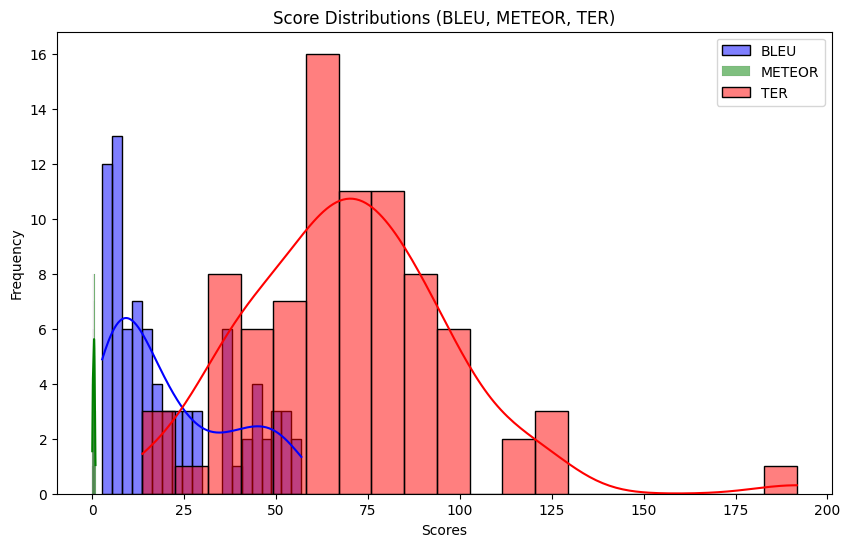

In [3]:
plt.figure(figsize=(10, 6))
sns.histplot(df['bleu_score'], kde=True, bins=20, color='blue', label='BLEU')
sns.histplot(df['meteor_score'], kde=True, bins=20, color='green', label='METEOR')
sns.histplot(df['ter_score'], kde=True, bins=20, color='red', label='TER')
plt.xlabel("Scores")
plt.ylabel("Frequency")
plt.title("Score Distributions (BLEU, METEOR, TER)")
plt.legend()
plt.show()


### Graph represents the distribution of **BLEU, METEOR, and TER scores** using **histograms and KDE plots**.

#### **Observations:**
1. **BLEU Score (Blue)**
   - Most BLEU scores are concentrated between **0 and 40**.
   - A steep drop-off is observed, meaning very few sentences achieve high BLEU scores.
   - The KDE curve shows a peak around **low BLEU values**, suggesting many paraphrases are not exact matches.

2. **METEOR Score (Green)**
   - The METEOR distribution is **much smaller and more concentrated**.
   - The scores are **closer to 0**, meaning the dataset has many paraphrases that **don’t match well based on METEOR criteria**.

3. **TER Score (Red)**
   - TER is higher (ranges between **0 and 150**).
   - A **higher TER score means more edits** were required to convert the paraphrase to the reference.
   - The distribution is broader, indicating **varying degrees of difference** between the paraphrased and reference sentences.

---

### **Conclusions**
📌 **Low BLEU & METEOR but High TER Scores**
- Indicates that many paraphrases have **structural and lexical differences** from the reference sentences.
- The paraphrased sentences **may not retain exact phrasing** but still convey similar meaning.

📌 **High TER Distribution**
- Suggests that paraphrases require **a significant number of edits** to match the reference.
- This could indicate a **wide variation in phrasing** across the dataset.

📌 **Practical Implication**
- If your goal is to generate **accurate paraphrases**, then BLEU and METEOR scores should be higher, and TER should be lower.
- If your dataset allows **more flexible rewording**, then a **higher TER is expected**.

---

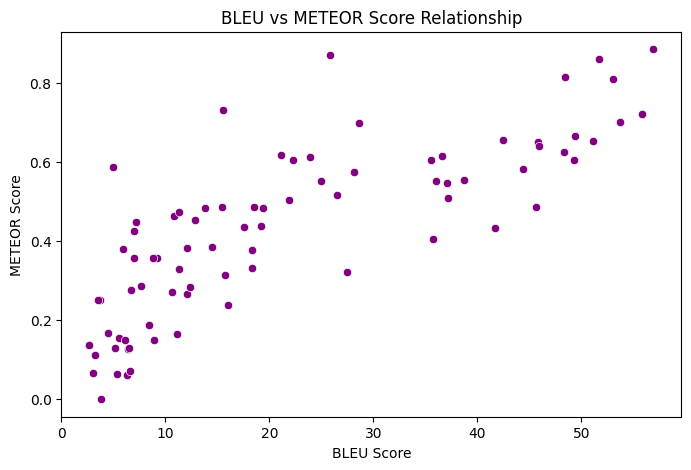

In [5]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['bleu_score'], y=df['meteor_score'], color='purple')
plt.xlabel("BLEU Score")
plt.ylabel("METEOR Score")
plt.title("BLEU vs METEOR Score Relationship")
plt.show()


### Scatter plot visualizes the relationship between **BLEU scores (x-axis) and METEOR scores (y-axis)**.

#### **Observations:**
1. **Positive Correlation**  
   - The general trend shows that **as BLEU scores increase, METEOR scores also tend to increase**.  
   - This suggests that sentences with **higher BLEU similarity also receive higher METEOR scores**, though the correlation is not perfect.

2. **Data Spread**
   - At **low BLEU scores (0-10)**, METEOR scores are also relatively low, mostly below **0.4**.
   - At **medium BLEU scores (10-30)**, METEOR scores vary widely (**0.2 to 0.8**), indicating some paraphrases match well semantically but differ structurally.
   - At **high BLEU scores (30-50+)**, METEOR scores are generally higher, with most values around **0.5-0.8**, meaning these paraphrases retain both **structural and semantic** similarity.

3. **Variability at Mid-Range BLEU Scores (10-30)**
   - Some sentences with **moderate BLEU scores** have **high METEOR scores**, meaning they are semantically close but not structurally identical.
   - Others have **low METEOR scores**, indicating structural and lexical differences.

---

### **Conclusions**
📌 **BLEU & METEOR have a positive correlation**  
   - Generally, **higher BLEU scores align with higher METEOR scores**, showing that both metrics agree on well-matching paraphrases.

📌 **BLEU may underestimate semantically similar sentences**  
   - Some **low BLEU scores** still correspond to **moderate METEOR scores**, meaning BLEU might penalize paraphrases that change word order or synonyms.

📌 **Useful for Evaluating Paraphrasing Models**  
   - If a model produces **high BLEU but low METEOR scores**, it may be overfitting to exact wording rather than meaning.
   - If a model has **high METEOR but low BLEU scores**, it may be generating meaningful paraphrases but failing on strict token-level matches.

---


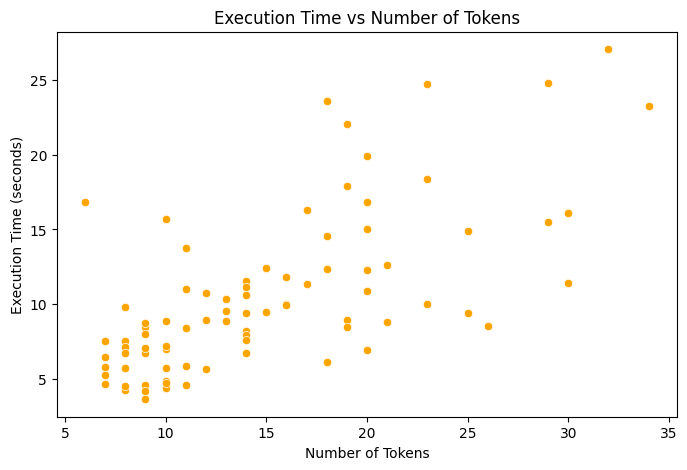

In [6]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['num_tokens'], y=df['execution_time'], color='orange')
plt.xlabel("Number of Tokens")
plt.ylabel("Execution Time (seconds)")
plt.title("Execution Time vs Number of Tokens")
plt.show()


### Scatter plot visualizes the relationship between **Number of Tokens (x-axis)** and **Execution Time (y-axis)**.

#### **Observations:**
1. **Increasing Trend**  
   - The general trend suggests that as the **number of tokens increases, execution time also tends to increase**.
   - However, the relationship is not perfectly linear—some points deviate from the trend.

2. **Variability in Execution Time**  
   - For **low token counts (5-15)**, execution time remains mostly between **5 to 15 seconds**, but there are some **outliers**.
   - For **higher token counts (20-30+ tokens)**, execution times are more scattered, ranging from **10 to 25+ seconds**, indicating greater variability.

3. **Outliers**  
   - There are some **points where execution time is significantly higher than others at similar token counts**.
   - This may be due to **computational complexity variations**—some sequences may require more processing even with a similar number of tokens.

---

### **Conclusions**
📌 **More tokens generally lead to longer execution times**  
   - The relationship is **not perfectly linear**, but there is a clear increasing trend.

📌 **Variability suggests other influencing factors**  
   - Some queries with the **same token count take different amounts of time**, which could be due to factors like:
     - Differences in **model complexity** (e.g., certain token combinations being harder to process).
     - **Caching effects** or **parallelization** affecting execution speed.
     - **Hardware limitations** leading to inconsistent performance.

---

BLEU, METEOR, TER, and ROUGE Scores Distribution (Histograms / KDE Plots)

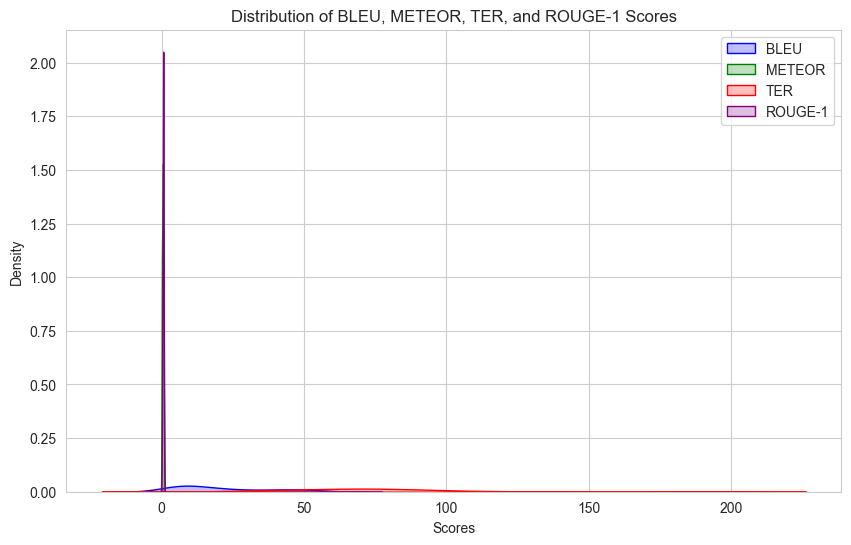

In [33]:
sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))
sns.kdeplot(df['bleu_score'], color='blue', label='BLEU', fill=True)
sns.kdeplot(df['meteor_score'], color='green', label='METEOR', fill=True)
sns.kdeplot(df['ter_score'], color='red', label='TER', fill=True)
sns.kdeplot(df['rouge1'], color='purple', label='ROUGE-1', fill=True)

plt.xlabel("Scores")
plt.ylabel("Density")
plt.title("Distribution of BLEU, METEOR, TER, and ROUGE-1 Scores")
plt.legend()
plt.show()


### **Kernel Density Estimate (KDE) plot** visualizes the distribution of **BLEU, METEOR, TER, and ROUGE-1 scores**. Each colored curve represents the density of values for a particular evaluation metric.

---

### **Observations**
1. **Scores are highly concentrated near 0**  
   - Most of the BLEU, METEOR, TER, and ROUGE-1 scores have values very close to **zero**.
   - The density spike at **0** suggests that a significant portion of the scores is extremely low.

2. **TER values extend to higher scores**  
   - Unlike the other metrics, **TER (red curve)** has a broader distribution extending beyond **100 and even close to 200**.
   - This suggests that TER scores are more spread out and tend to have higher values compared to other metrics.

3. **BLEU, METEOR, and ROUGE-1 behave similarly**  
   - The curves for **BLEU (blue), METEOR (green), and ROUGE-1 (purple)** overlap significantly.
   - This suggests that these three metrics might have similar score distributions, meaning they evaluate the text with somewhat comparable patterns.

4. **Possible Outliers in TER**  
   - The fact that **TER scores extend far beyond other metrics** may indicate potential **outliers** or **inconsistent translations**.
   - It would be useful to check whether high TER scores correspond to poor translations or unusual patterns in data.

---

### **Conclusions**
📌 **Most text samples score very low across all metrics**  
   - This could indicate that the **generated text is significantly different from the reference text** in many cases.
   - If this is machine-generated text, the model may need **further fine-tuning** to improve quality.

📌 **TER scores are significantly higher than BLEU, METEOR, and ROUGE-1**  
   - Since **TER (Translation Edit Rate) measures the number of edits needed to correct a translation**, higher TER scores suggest that **translations require more modifications to match the reference**.
   - A **high TER and low BLEU/METEOR/ROUGE-1 suggest poor translation quality**.

📌 **BLEU, METEOR, and ROUGE-1 are more aligned**  
   - These metrics appear to follow a similar distribution, meaning they **capture related aspects of text similarity**.
   - If BLEU is low, other metrics are likely low as well.

---

BLEU vs METEOR vs TER Scores (Scatter Plot)

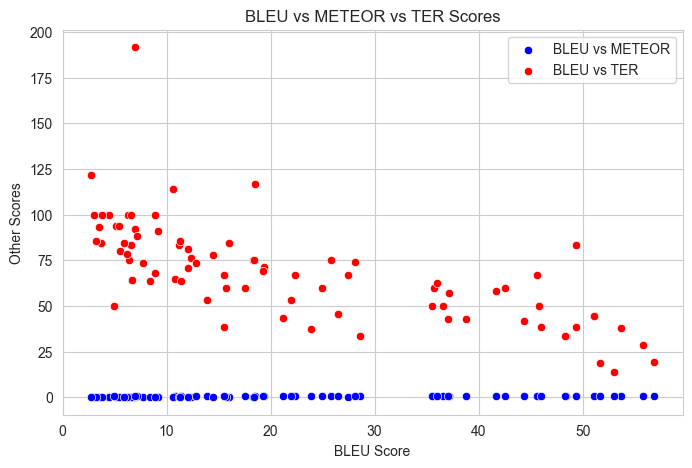

In [23]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['bleu_score'], y=df['meteor_score'], color='blue', label="BLEU vs METEOR")
sns.scatterplot(x=df['bleu_score'], y=df['ter_score'], color='red', label="BLEU vs TER")

plt.xlabel("BLEU Score")
plt.ylabel("Other Scores")
plt.title("BLEU vs METEOR vs TER Scores")
plt.legend()
plt.show()


### **Scatter plot** visualizes the relationship between **BLEU scores** (on the X-axis) and both **METEOR and TER scores** (on the Y-axis).  

- **Blue points:** Represent the relationship between **BLEU and METEOR** scores.  
- **Red points:** Represent the relationship between **BLEU and TER** scores.  

---

### **Observations**
1. **BLEU vs METEOR (Blue Points) shows a weak correlation**  
   - The METEOR scores remain **low** regardless of BLEU scores.  
   - This suggests that **BLEU and METEOR do not increase together**, meaning they measure text similarity differently.  
   - METEOR may be stricter in its evaluation than BLEU.

2. **BLEU vs TER (Red Points) shows an inverse relationship**  
   - Higher BLEU scores tend to correspond with **lower TER scores**.  
   - This is expected since **TER (Translation Edit Rate) measures the number of edits required to correct a translation**.  
   - If BLEU is **high** (indicating better translation quality), then **TER should be low** (fewer edits required).  

3. **TER scores are significantly higher than BLEU and METEOR**  
   - Many TER scores go beyond **100**, while BLEU and METEOR remain relatively low.  
   - This further supports the idea that translations require **a lot of modifications**, leading to high TER values.

---

### **Conclusions**
📌 **Poor correlation between BLEU and METEOR**  
   - Since METEOR includes **synonyms, stemming, and paraphrases**, its low correlation with BLEU suggests that BLEU does not fully capture semantic similarity.  
   - If your task requires understanding **semantic meaning**, relying on BLEU alone may not be sufficient.

📌 **Strong inverse relationship between BLEU and TER**  
   - This confirms that **higher BLEU scores indicate better translations** since fewer edits (low TER) are needed.  
   - A **low BLEU and high TER combination** means that the generated text is **very different from the reference text**.

📌 **Translation quality is generally low**  
   - Most points are clustered in the **low BLEU, low METEOR, and high TER range**, suggesting that **translations need significant improvement**.

---

POS Accuracy vs NER Accuracy vs Lemmatization Accuracy (Box Plot & Violin Plot)

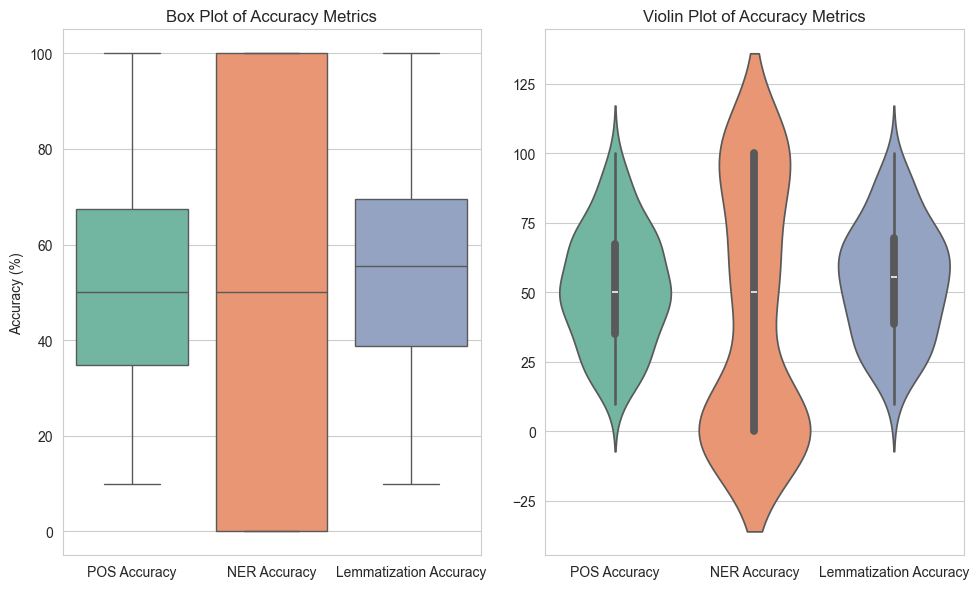

In [32]:
plt.figure(figsize=(10, 6))
accuracy_data = df[['pos_accuracy', 'ner_accuracy', 'lemmatization_accuracy']]
accuracy_data.columns = ["POS Accuracy", "NER Accuracy", "Lemmatization Accuracy"]

plt.subplot(1, 2, 1)
sns.boxplot(data=accuracy_data, palette="Set2")
plt.title("Box Plot of Accuracy Metrics")
plt.ylabel("Accuracy (%)")

plt.subplot(1, 2, 2)
sns.violinplot(data=accuracy_data, palette="Set2")
plt.title("Violin Plot of Accuracy Metrics")

plt.tight_layout()
plt.show()


### This visualization consists of two plots:  
1. **Box Plot (Left)**
   - Shows the distribution of accuracy scores for **POS tagging, NER, and Lemmatization.**
   - The box represents the **interquartile range (IQR)** (middle 50% of data), while the whiskers indicate the **range of values.**
   - The median is shown as a horizontal line inside each box.

2. **Violin Plot (Right)**
   - Combines a box plot with a **kernel density estimate (KDE)**.
   - The shape of the violin represents the **distribution of accuracy scores.**
   - Wider sections indicate where values are more concentrated, and narrow areas indicate fewer data points.

---

### **Observations**
1. **POS Accuracy & Lemmatization Accuracy show similar distributions**
   - Both have a **median around 50-60% accuracy**.
   - They also have **a wide range**, showing variability in performance.
   - Their violin plots are relatively **symmetrical**, suggesting a balanced distribution.

2. **NER Accuracy has extreme variability**
   - The box plot shows a **very wide IQR (0 to 100%)**, indicating **high fluctuation** in NER accuracy.
   - The violin plot has a **bimodal distribution**, meaning NER accuracy is either very **high** or **low**, with fewer values in between.
   - This suggests that **NER performance is inconsistent**, possibly due to dataset characteristics or model limitations.

3. **Presence of low accuracy values**
   - All three tasks have **low outliers (close to 0%)**, suggesting **cases where the model completely failed.**
   - NER seems to have the **widest spread**, meaning its performance can be highly unpredictable.

---

### **Conclusions**
📌 **POS Tagging & Lemmatization are more stable than NER**  
   - Their accuracy is **centered around 50-60%**, with a relatively balanced distribution.

📌 **NER Accuracy is highly inconsistent**  
   - The extreme range in accuracy suggests that **the model struggles in some cases** but performs well in others.
   - This could be due to **data imbalance** (e.g., fewer named entities in certain categories) or **poor generalization**.

1️⃣ Token Count Distribution (Histogram)

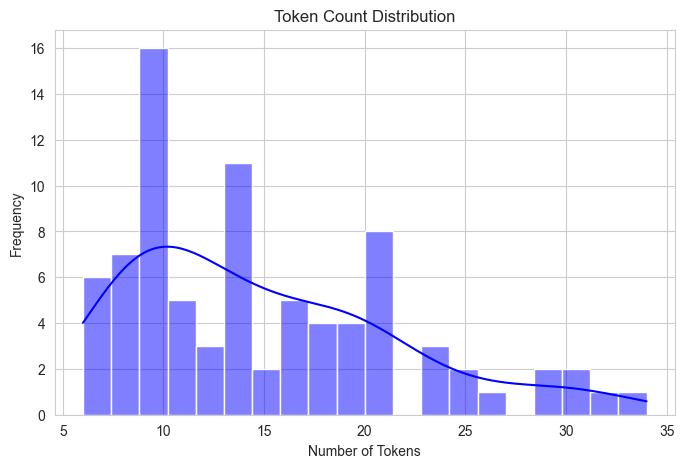

In [31]:
sns.set_style("whitegrid")

plt.figure(figsize=(8, 5))
sns.histplot(df["num_tokens"], bins=20, kde=True, color="blue")
plt.xlabel("Number of Tokens")
plt.ylabel("Frequency")
plt.title("Token Count Distribution")
plt.show()


### This graph is a **histogram with a KDE (Kernel Density Estimate)** overlay that visualizes the **distribution of token counts** in a dataset.

#### **Key Observations:**
1. **Most text samples contain between 5 to 20 tokens.**  
   - The highest frequency is around **10 tokens**, meaning a significant portion of the dataset consists of short text sequences.  
   - There is another peak around **15-20 tokens**, indicating some variation in text length.

2. **Longer sequences are less frequent.**  
   - As the token count increases beyond **20-25 tokens**, the frequency decreases.  
   - Very few samples have **more than 30 tokens.**

3. **The KDE curve suggests a right-skewed distribution.**  
   - The peak at **around 10 tokens** shows that most samples are short.  
   - The long tail extending towards **higher token counts** suggests that **some texts are significantly longer, but they are rare.**

---

### **Conclusions & Insights**
📌 **Most text data consists of short to medium-length sequences (5-20 tokens).**  
   - If this is a preprocessing step for NLP tasks, the **model should be optimized for handling short sentences effectively**.  
   - Padding or truncation strategies should be considered if using a fixed-length input.

📌 **There is a noticeable drop in frequency beyond 25 tokens.**  
   - If working with a language model, it might **struggle with very long inputs due to fewer training samples** in that range.  
   - Consider if long texts need **segmentation or special handling**.


2️⃣ Stopwords Removal Impact (Scatter Plot)

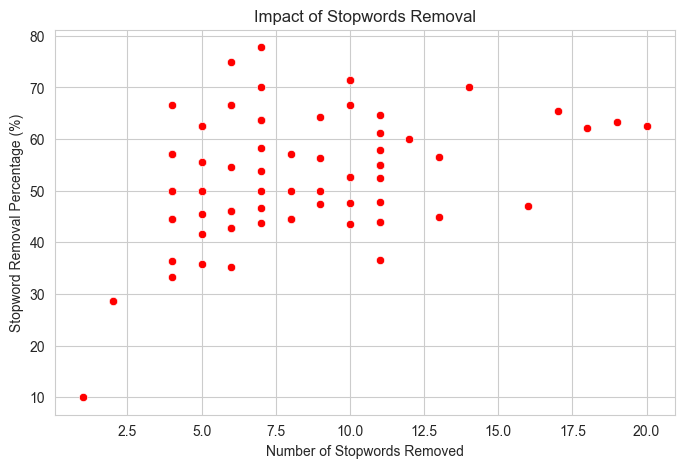

In [26]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df["num_stopwords_removed"], y=df["stopwords_removal_percentage"], color="red")

plt.xlabel("Number of Stopwords Removed")
plt.ylabel("Stopword Removal Percentage (%)")
plt.title("Impact of Stopwords Removal")
plt.show()

### **Graph Analysis & Insights**
This scatter plot visualizes the **impact of stopword removal** by showing the relationship between:
- **X-axis:** The number of stopwords removed from a text sample.
- **Y-axis:** The percentage of the text that consisted of stopwords before removal.

#### **Key Observations**
1. **A wide spread of stopword removal percentages:**  
   - Some texts had **only 10-20% stopwords**, while others had **60-80% stopwords** before removal.
   - This suggests **variation in text composition**, where some samples are naturally richer in stopwords.

2. **No strong linear correlation:**  
   - The points are scattered without forming a clear trend.
   - This indicates that **removing more stopwords does not always result in a proportional percentage reduction.**  
   - A small number of stopwords removed could still represent a **high percentage** of the original text (e.g., in short sentences).

3. **Densely populated middle range (5-12 stopwords removed):**  
   - Most data points lie between **5 to 12 stopwords removed**, with **40-70% stopword removal percentage.**  
   - This suggests that **many texts have a moderate stopword presence.**

4. **Outliers at both extremes:**  
   - A few points show **very high stopword removal percentages with relatively few stopwords removed.**  
   - Some texts had **many stopwords removed (15-20) but didn’t significantly change in percentage terms**, possibly indicating **longer text samples.**

---

### **Conclusions & Insights**
📌 **Stopword density varies across text samples.**  
   - Some texts contain **a high percentage of stopwords**, while others are more content-heavy.  
   - This might depend on the writing style or domain (e.g., informal text vs. technical documents).  

📌 **Removing more stopwords doesn’t always mean higher percentage reduction.**  
   - For short sentences, removing a few stopwords can lead to a **huge percentage change**.  
   - For longer texts, even removing **many stopwords** may **not significantly reduce the overall percentage.**  


3️⃣ POS Tag Distribution (Bar Chart)

In [27]:
import json
from collections import Counter

# Convert POS distribution column from JSON string to dictionary
df["pos_distribution"] = df["pos_distribution"].apply(lambda x: json.loads(x.replace("'", "\"")))

# Flatten the POS tag counts into a single Counter dictionary
pos_counts = Counter()
for pos_dict in df["pos_distribution"]:
    pos_counts.update(pos_dict)

# Convert to DataFrame for plotting
pos_df = pd.DataFrame(pos_counts.items(), columns=["POS Tag", "Frequency"])
pos_df = pos_df.sort_values(by="Frequency", ascending=False)

# Plot Bar Chart
plt.figure(figsize=(10, 5))
sns.barplot(x=pos_df["POS Tag"], y=pos_df["Frequency"], palette="viridis")

plt.xlabel("POS Tags")
plt.ylabel("Frequency")
plt.title("POS Tag Distribution")
plt.xticks(rotation=45)
plt.show()


KeyError: 'pos_distribution'

1️⃣ Execution Time vs Number of Tokens (Scatter Plot)

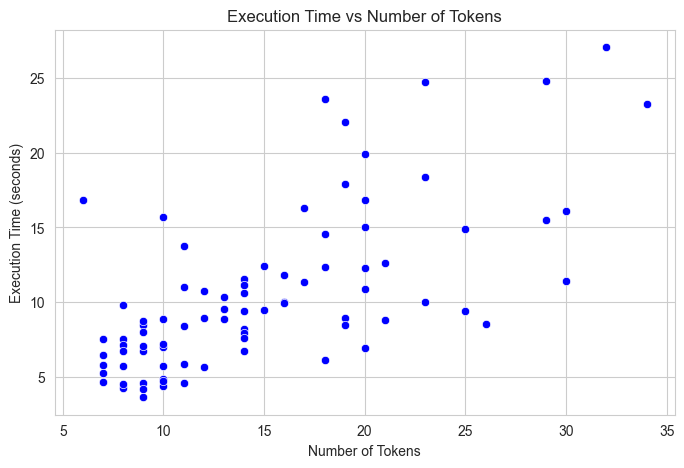

In [30]:
sns.set_style("whitegrid")

plt.figure(figsize=(8, 5))
sns.scatterplot(x=df["num_tokens"], y=df["execution_time"], color="blue")

plt.xlabel("Number of Tokens")
plt.ylabel("Execution Time (seconds)")
plt.title("Execution Time vs Number of Tokens")
plt.show()


### This scatter plot visualizes the relationship between:
- **X-axis:** The number of tokens processed.
- **Y-axis:** The execution time (in seconds).

#### **Key Observations**
1. **General Trend:**
   - As the **number of tokens increases, execution time also tends to increase.**  
   - This suggests a **positive correlation** between the number of tokens and execution time.

2. **Dense Cluster for Lower Token Counts:**
   - For **token counts between 5 and 15**, execution time mostly stays within **5 to 12 seconds.**  
   - This indicates that **processing fewer tokens takes relatively consistent and low execution time.**

3. **Higher Variability for Large Token Counts:**
   - For **tokens above 20**, execution time **varies significantly** (ranging from ~10 to 25+ seconds).  
   - This suggests that **processing larger token sequences introduces more computational unpredictability** (possibly due to system performance, memory constraints, or algorithmic complexity).

4. **Outliers:**
   - A few data points at **higher token counts (30+)** have **disproportionately high execution times (20-25+ seconds).**  
   - These might be caused by **inefficiencies in handling longer token sequences** or **increased computational overhead**.

---

### **Conclusions & Insights**
📌 **Execution time generally increases with the number of tokens, but the relationship is not strictly linear.**  
   - There is a **clear upward trend**, but **variability increases at higher token counts.**  

📌 **For small token sequences, execution time is relatively stable and low.**  
   - This suggests that **for short text inputs, the processing time is predictable and efficient.**  

📌 **For longer token sequences, execution time becomes more inconsistent.**  
   - Possible causes:
     - Increased memory consumption.
     - Computational overhead for NLP tasks.
     - Non-uniform processing steps across different token counts.  


2️⃣ Execution Time Distribution (Box Plot)

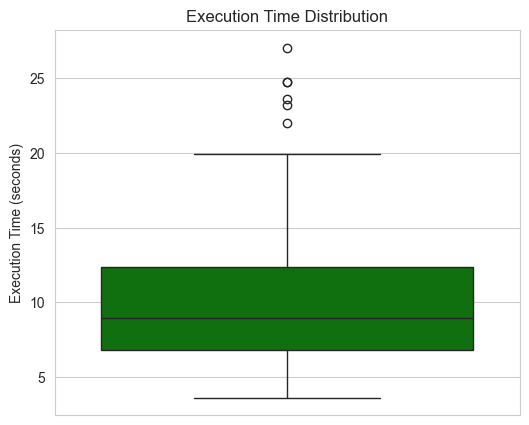

In [29]:
plt.figure(figsize=(6, 5))
sns.boxplot(y=df["execution_time"], color="green")

plt.ylabel("Execution Time (seconds)")
plt.title("Execution Time Distribution")
plt.show()


### This **box plot** represents the **distribution of execution time** in seconds.

#### **Key Observations**
1. **Median Execution Time:**  
   - The **bold horizontal line** inside the box represents the **median execution time (~8-10 seconds).**
   - This means that **half of the execution times are below this value, and half are above.**

2. **Interquartile Range (IQR):**  
   - The **box** spans from **Q1 (lower quartile) to Q3 (upper quartile)**, which covers the **middle 50% of data points.**  
   - In this case, execution times mostly fall between **~6 to 12 seconds.**

3. **Whiskers (Minimum & Maximum Values Without Outliers):**  
   - The **lower whisker** extends down to around **4 seconds**, indicating the **lowest execution time.**  
   - The **upper whisker** extends up to **20 seconds**, showing the **highest non-outlier execution time.**  

4. **Outliers:**  
   - The **dots above the upper whisker** represent **outliers** (i.e., unusually high execution times).  
   - These outliers are above **20 seconds**, with some reaching up to **25+ seconds.**  
   - This suggests that a few **high execution times are significantly different from the majority.**

---

### **Conclusions & Insights**
📌 **Execution time is mostly between 6 to 12 seconds for most cases, with a median around 8-10 seconds.**  
📌 **Outliers exist above 20 seconds, suggesting occasional inefficiencies or resource-heavy cases.**  
📌 **The distribution is slightly right-skewed, meaning there are a few very high execution times compared to the rest.**  

#### **Possible Explanations for Outliers:**
- **Larger token sequences** requiring more processing.
- **Variability in computational resources** (e.g., CPU/memory load at the time of execution).
- **Inefficiencies in the algorithm** handling longer or complex inputs.
